### Detection psychometric function
Edit the numbers marked `👈` and re-run.

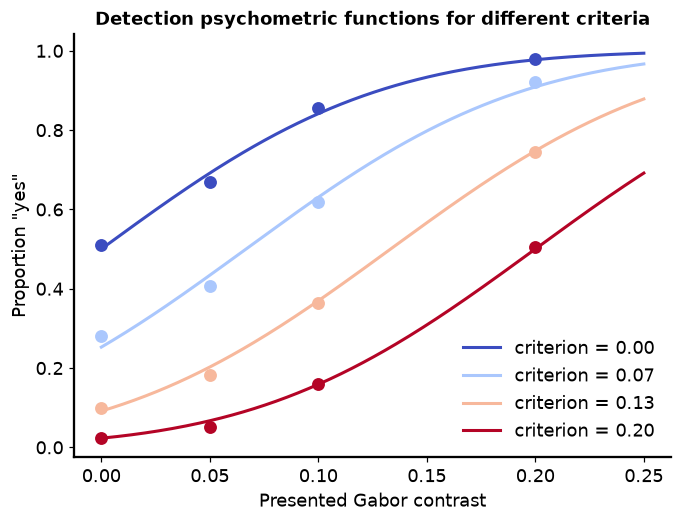

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# A yes/no detection task: contrast varies, observer says "yes" above a criterion
signal_strengths = np.array([0, 0.05, 0.1, 0.2])   # 👈 Gabor contrasts presented
noise_sd = 0.1                                       # 👈 internal noise
ntrials  = 1000
criteria = np.linspace(0, 0.2, 4)                    # liberal (low) -> conservative (high)

rng = np.random.default_rng()
# internal value = contrast + noise, for each presented contrast
samples = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd + signal_strengths

# proportion of "yes" responses for each contrast (rows) and criterion (cols)
p_yes = np.array([[(samples[:, si] > c).mean() for c in criteria]
                  for si in range(signal_strengths.size)])

colours = plt.cm.coolwarm(np.linspace(0, 1, criteria.size))   # blue=liberal, red=conservative
xs = np.linspace(0, 0.25, 200)

fig, ax = plt.subplots(figsize=(7, 5))
for ci, c in enumerate(criteria):
    ax.scatter(signal_strengths, p_yes[:, ci], 55, color=colours[ci], zorder=3)
    ax.plot(xs, norm.cdf(xs, c, noise_sd), color=colours[ci], lw=2,
            label=f"criterion = {c:.2f}")
ax.set(xlabel="Presented Gabor contrast", ylabel='Proportion "yes"',
       title="Detection psychometric functions for different criteria")
ax.legend()
plt.show()
